In [35]:
# Library yang digunakan
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from collections import Counter


## 💡 Load Data

In [36]:
#Load Dataser

version_5_5 = f"../data/review_genshin_5.5_clear.csv"
version_5_4 = f"../data/review_genshin_5.4_clear.csv"
version_5_3 = f"../data/review_genshin_5.3_clear.csv"
review_5_5 = pd.read_csv(version_5_5)
review_5_4 = pd.read_csv(version_5_4)
review_5_3 = pd.read_csv(version_5_3)

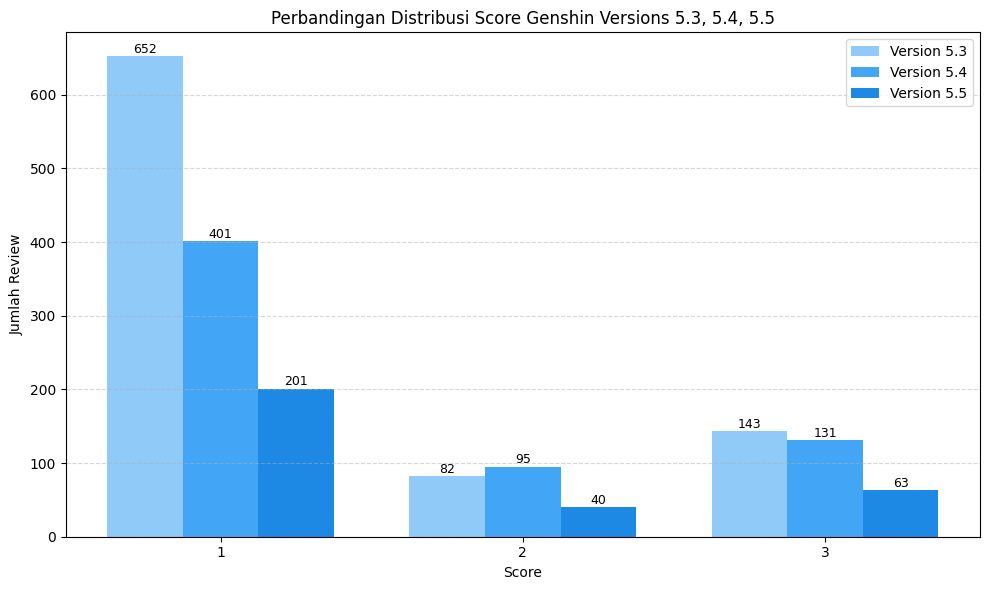

In [37]:
# Hitung jumlah score masing-masing versi
score_5_5 = review_5_5['Score'].value_counts().sort_index()
score_5_4 = review_5_4['Score'].value_counts().sort_index()
score_5_3 = review_5_3['Score'].value_counts().sort_index()

# Gabungkan semua score dari 1 sampai 5
all_scores = sorted(set(score_5_3.index) | set(score_5_4.index) | set(score_5_5.index))

# Reindex agar semua score ada
score_5_3 = score_5_3.reindex(all_scores, fill_value=0)
score_5_4 = score_5_4.reindex(all_scores, fill_value=0)
score_5_5 = score_5_5.reindex(all_scores, fill_value=0)

# Setup posisi x dan lebar bar
x = np.arange(len(all_scores))
width = 0.25

# Plot barplot
fig, ax = plt.subplots(figsize=(10, 6))
bar1 = ax.bar(x - width, score_5_3.values, width, label='Version 5.3', color='#90CAF9')
bar2 = ax.bar(x, score_5_4.values, width, label='Version 5.4', color='#42A5F5')
bar3 = ax.bar(x + width, score_5_5.values, width, label='Version 5.5', color='#1E88E5')

# Tambahkan label jumlah di atas setiap bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(height),
                ha='center', va='bottom', fontsize=9)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Konfigurasi tampilan
ax.set_xlabel('Score')
ax.set_ylabel('Jumlah Review')
ax.set_title('Perbandingan Distribusi Score Genshin Versions 5.3, 5.4, 5.5')
ax.set_xticks(x)
ax.set_xticklabels([str(score) for score in all_scores])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

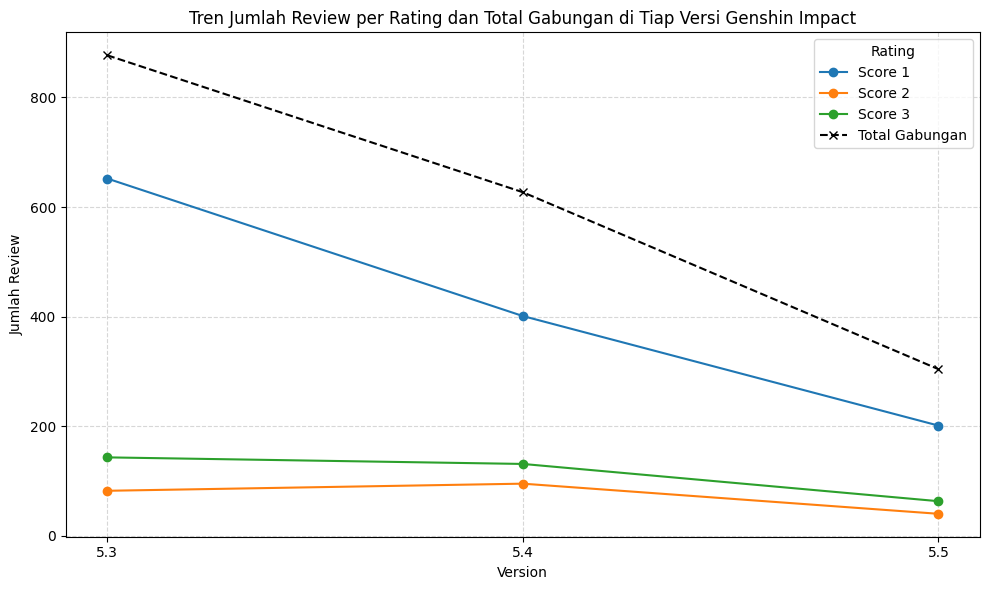

In [38]:
# Daftar file dan versi
version_files = {
    '5.3': '../data/review_genshin_5.3_clear.csv',
    '5.4': '../data/review_genshin_5.4_clear.csv',
    '5.5': '../data/review_genshin_5.5_clear.csv',
}

# Inisialisasi DataFrame kosong
all_data = pd.DataFrame()
total_data = pd.DataFrame()

# Loop semua versi
for version, file in version_files.items():
    df = pd.read_csv(file)
    score_count = df['Score'].value_counts().sort_index()
    score_count.name = version  # ganti nama series menjadi versi
    all_data = pd.concat([all_data, score_count], axis=1)
    
    # Total review gabungan per version (jumlah semua rating)
    total_review = df['Score'].count()
    total_data[version] = [total_review] * len(score_count)

# Pastikan index-nya (score) urut
all_data = all_data.fillna(0).astype(int).sort_index()
total_data = total_data.fillna(0)

# Transpose agar versi jadi index, lalu plot per score dan total gabungan
plt.figure(figsize=(10, 6))

# Plot per rating (Score 1, Score 2, dst.)
for score in all_data.index:
    plt.plot(all_data.columns, all_data.loc[score], marker='o', label=f'Score {score}')

# Plot total gabungan per versi
plt.plot(total_data.columns, total_data.iloc[0], marker='x', linestyle='--', label='Total Gabungan', color='black')

# Label dan tampilan
plt.title('Tren Jumlah Review per Rating dan Total Gabungan di Tiap Versi Genshin Impact')
plt.xlabel('Version')
plt.ylabel('Jumlah Review')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Rating')
plt.tight_layout()
plt.show()

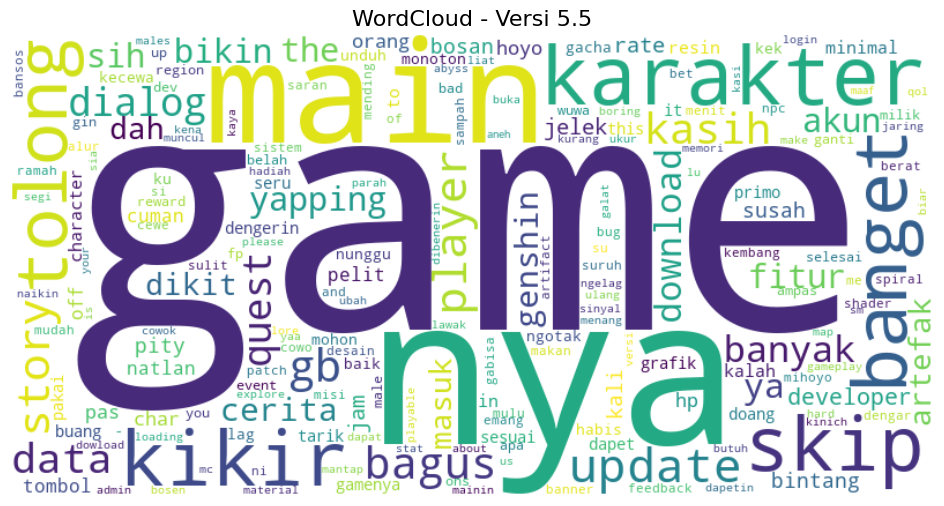

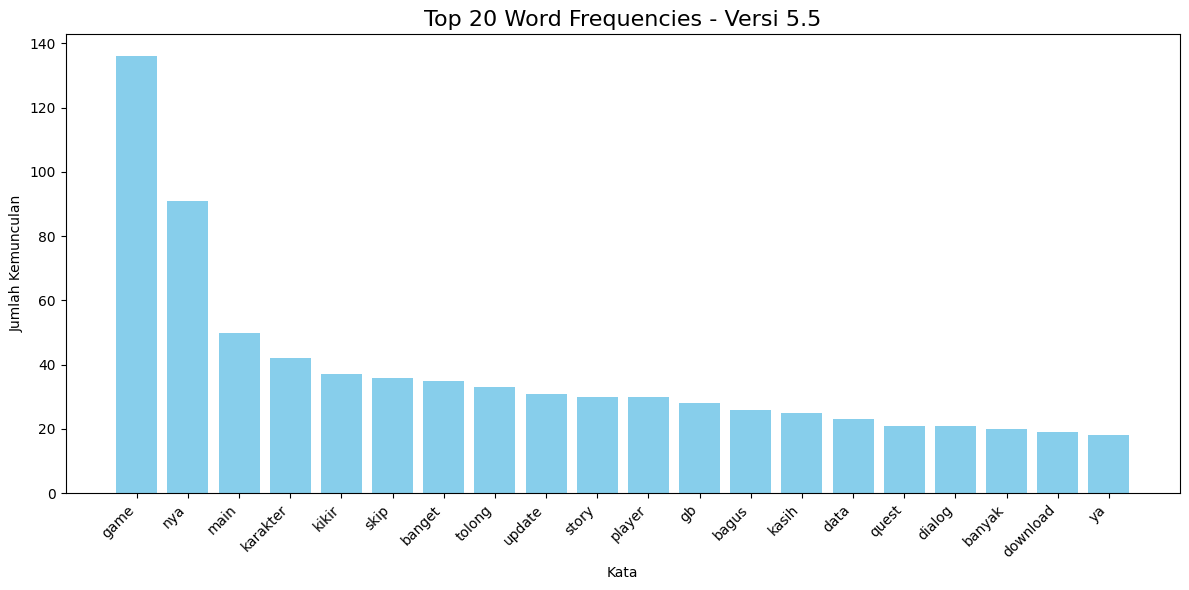

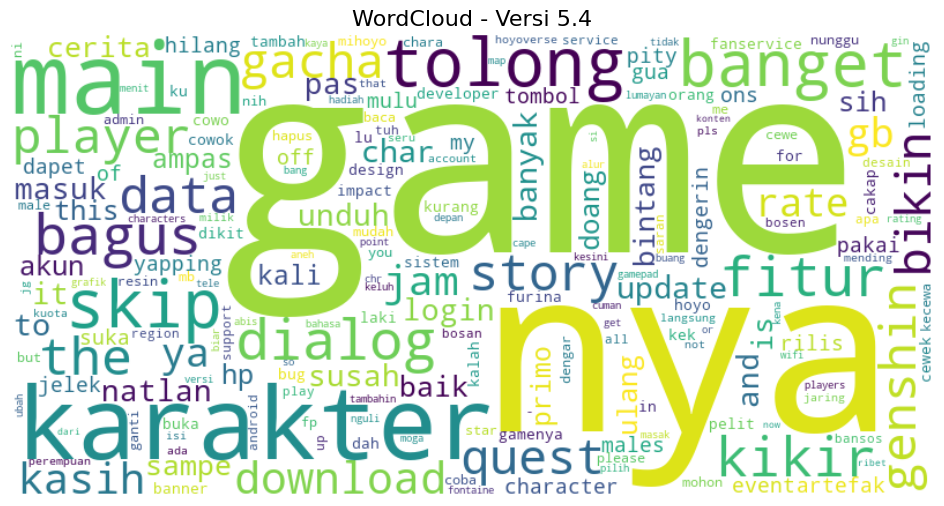

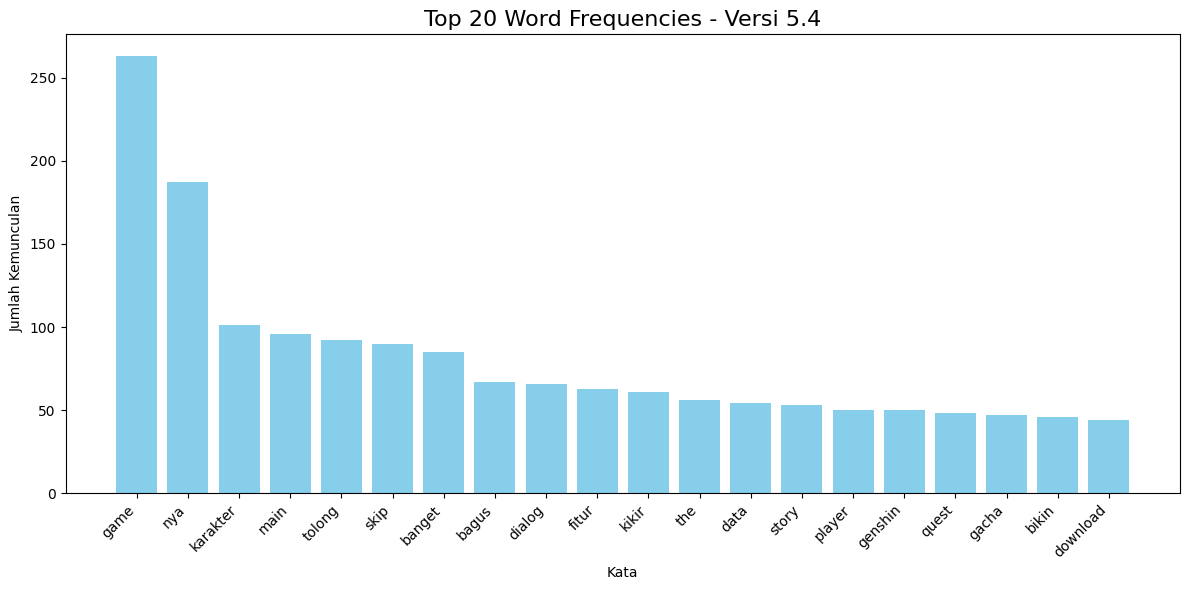

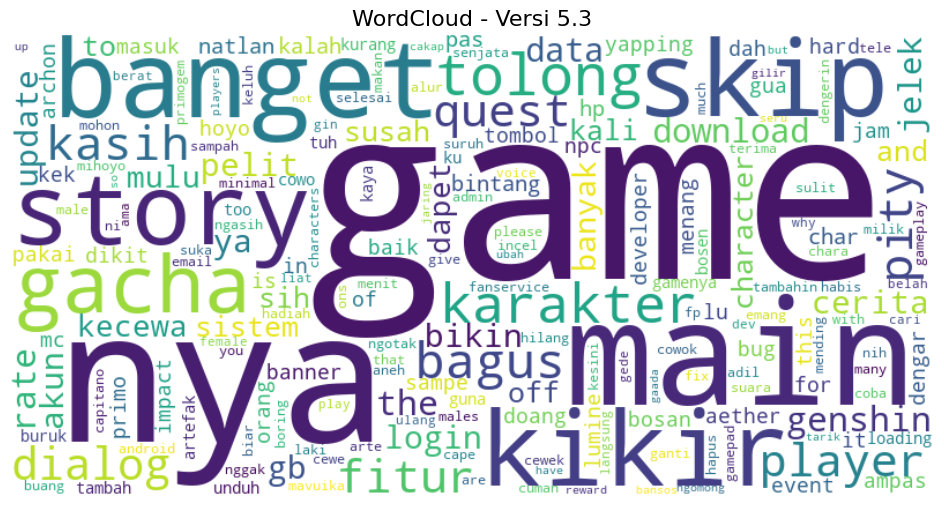

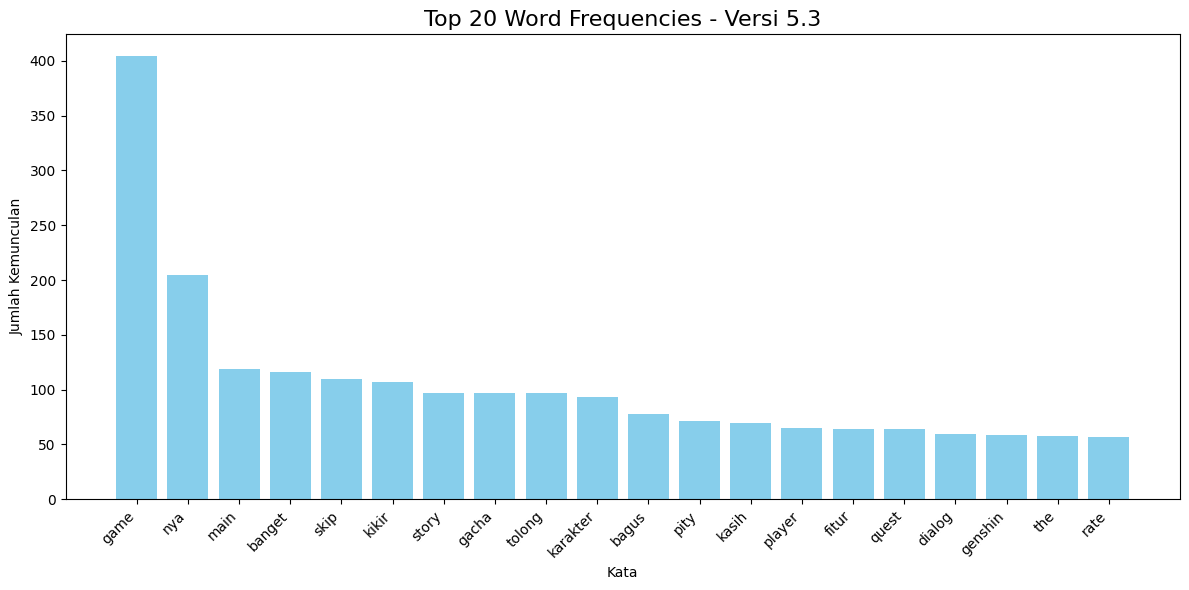

In [39]:
# Fungsi untuk membuat visualisasi WordCloud dan Bar Chart dari DataFrame
def visualize_word_frequency(df, judul=''):
    # Gabungkan semua teks dari kolom Content
    all_text = ' '.join(df['Content'].astype(str)).lower()

    # Tokenisasi
    words = all_text.split()

    # Hitung frekuensi kata
    word_counts = Counter(words)

    # Ambil 20 kata teratas
    most_common_words = word_counts.most_common(20)
    words_labels, words_values = zip(*most_common_words)

    # WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud - {judul}', fontsize=16)
    plt.show()

    # Bar Chart
    plt.figure(figsize=(12, 6))
    plt.bar(words_labels, words_values, color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top 20 Word Frequencies - {judul}', fontsize=16)
    plt.xlabel('Kata')
    plt.ylabel('Jumlah Kemunculan')
    plt.tight_layout()
    plt.show()

# Load Dataset
version_5_5 = "../data/review_genshin_5.5_clear.csv"
version_5_4 = "../data/review_genshin_5.4_clear.csv"
version_5_3 = "../data/review_genshin_5.3_clear.csv"

review_5_5 = pd.read_csv(version_5_5)
review_5_4 = pd.read_csv(version_5_4)
review_5_3 = pd.read_csv(version_5_3)

# Visualisasi per versi
visualize_word_frequency(review_5_5, judul='Versi 5.5')
visualize_word_frequency(review_5_4, judul='Versi 5.4')
visualize_word_frequency(review_5_3, judul='Versi 5.3')